In [2]:
import json
import os
import urllib
import ssl

def download_and_load_file(file_path, url):
    ssl_context = ssl.create_default_context()
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

    if not os.path.exists(file_path):
        with urllib.request.urlopen(url, context=ssl_context) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data


file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [3]:
def format_input(entry):
    instruction_text=(
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Input:\n{entry['instruction']}"
    )
    
    input_text=f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text+input_text

In [4]:
train_ratio=0.85
test_ratio=0.10
train_portion=int(len(data)*train_ratio)
test_portion=int(len(data)*test_ratio)
train_data=data[:train_portion]
test_data=data[train_portion:train_portion+test_portion]
val_data=data[train_portion+test_portion:]

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import tensorflow as tf

In [6]:
device=torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

In [7]:
class InstructionDataset(Dataset):
    def __init__(self,data,tokenizer):
        self.data=data
        self.encoded_data=[]
        for entry in data:
            instruction_plus_input=format_input(entry)
            response_text=f"\n\n### Response:\n{entry['output']}"
            full_text=instruction_plus_input+response_text
            self.encoded_data.append(tokenizer.encode(full_text))
    def __len__(self):
        return len(self.data)
    def __getitem__(self,index):
        return self.encoded_data[index]
    
        

In [8]:
def custom_collate_function(batch,pad_token_id=50256,ignore_index=-100,allowed_max_length=None,device='cpu'):
    batch_max_length=max(len(item)+1 for item in batch)
    input_lst,target_lst=[],[]
    for item in batch:
        new_item=item.copy()
        new_item+=[pad_token_id]
        padded=(new_item+ [pad_token_id]*(batch_max_length-len(new_item)))
        inputs=torch.tensor(padded[:-1])
        outputs=torch.tensor(padded[1:])
        mask=(outputs==pad_token_id)
        indices=torch.nonzero(mask).squeeze()
        if indices.numel()>1:
            outputs[indices[1:]]=ignore_index
        if allowed_max_length is not None:
            inputs=inputs[:allowed_max_length]
            outputs=outputs[:allowed_max_length]
        input_lst.append(inputs)
        target_lst.append(outputs)
    inputs_tensor = torch.stack(input_lst).to(device)
    targets_tensor = torch.stack(target_lst).to(device)
    return inputs_tensor,targets_tensor

In [9]:
def create_dataloader(data,batch_size,collate_fn,tokenizer,drop_last):
    dataset=InstructionDataset(data,tokenizer)
    data_loaded=DataLoader(dataset,batch_size=batch_size,collate_fn=collate_fn,shuffle=False,drop_last=drop_last)
    return data_loaded

In [13]:
import tiktoken

In [14]:
tokenizer=tiktoken.get_encoding('gpt2')

In [15]:
from functools import partial
collate_fn=partial(custom_collate_function,device=device,allowed_max_length=1024)

In [16]:
batch_size=8
train_loader=create_dataloader(train_data,batch_size=batch_size,collate_fn=collate_fn,tokenizer=tokenizer,drop_last=True)
val_loader=create_dataloader(val_data,batch_size=batch_size,collate_fn=collate_fn,tokenizer=tokenizer,drop_last=False)
test_loader=create_dataloader(test_data,batch_size=batch_size,collate_fn=collate_fn,tokenizer=tokenizer,drop_last=False)

In [22]:
from gpt2_architecture import GPTModel

In [23]:
from  gpt_download3 import download_and_load_gpt2

In [24]:
base_config={"vocab_size":50257,"context_length":1024,"embed_dim":768,"num_heads":12,"n_layers":12,"dropout":0.0,"qkv_bias":True}

In [25]:
base_config.update({'embed_dim':1024,'num_heads':16,'n_layers':24})

In [26]:
settings,params=download_and_load_gpt2(model_size="355M",models_dir="gpt2")

/opt/anaconda3/envs/tf/lib/python3.12/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2/355M/checkpoint


/opt/anaconda3/envs/tf/lib/python3.12/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2/355M/encoder.json


/opt/anaconda3/envs/tf/lib/python3.12/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

File already exists and is up-to-date: gpt2/355M/model.ckpt.index


/opt/anaconda3/envs/tf/lib/python3.12/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2/355M/model.ckpt.meta


/opt/anaconda3/envs/tf/lib/python3.12/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


File already exists and is up-to-date: gpt2/355M/vocab.bpe


In [27]:
from gpt2_architecture import load_weights_into_model

In [28]:
model=GPTModel(base_config)
load_weights_into_model(model,params)

In [29]:
model.eval()

GPTModel(
  (token_embedding): Embedding(50257, 1024)
  (pos_embedding): Embedding(1024, 1024)
  (dropout): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (w_query): Linear(in_features=1024, out_features=1024, bias=True)
        (w_key): Linear(in_features=1024, out_features=1024, bias=True)
        (w_value): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (out_projection): Linear(in_features=1024, out_features=1024, bias=True)
      )
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
      (neural_net): FFNN(
        (network): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GeLU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention

In [30]:
model.to(device)

GPTModel(
  (token_embedding): Embedding(50257, 1024)
  (pos_embedding): Embedding(1024, 1024)
  (dropout): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (w_query): Linear(in_features=1024, out_features=1024, bias=True)
        (w_key): Linear(in_features=1024, out_features=1024, bias=True)
        (w_value): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (out_projection): Linear(in_features=1024, out_features=1024, bias=True)
      )
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
      (neural_net): FFNN(
        (network): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GeLU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention

In [31]:
from gpt2_architecture import generate_new_text,text_to_token_ids,token_ids_to_text,train_model

In [32]:
optimizer=torch.optim.AdamW(model.parameters(),lr=0.0005,weight_decay=0.1)
num_epochs=1
train_losses,val_losses=train_model(model,train_loader,val_loader,optimizer,device=device,num_epochs=num_epochs,eval_freq=5,eval_iter=5)

Ep 1 (step 000000): Train loss:4.156, Val loss:4.272
Ep 6 (step 000005): Train loss:5.671, Val loss:6.066
Ep 11 (step 000010): Train loss:2.990, Val loss:3.536
Ep 16 (step 000015): Train loss:2.072, Val loss:2.382
Ep 21 (step 000020): Train loss:1.659, Val loss:2.050
Ep 26 (step 000025): Train loss:1.388, Val loss:1.674
Ep 31 (step 000030): Train loss:1.242, Val loss:1.517
Ep 36 (step 000035): Train loss:1.158, Val loss:1.400
Ep 41 (step 000040): Train loss:1.080, Val loss:1.332
Ep 46 (step 000045): Train loss:1.091, Val loss:1.230
Ep 51 (step 000050): Train loss:1.004, Val loss:1.133
Ep 56 (step 000055): Train loss:0.906, Val loss:1.039
Ep 61 (step 000060): Train loss:1.062, Val loss:1.209
Ep 66 (step 000065): Train loss:0.856, Val loss:1.028
Ep 71 (step 000070): Train loss:0.725, Val loss:0.910
Ep 76 (step 000075): Train loss:0.725, Val loss:0.880
Ep 81 (step 000080): Train loss:0.716, Val loss:0.896
Ep 86 (step 000085): Train loss:0.663, Val loss:0.858
Ep 91 (step 000090): Train los

In [35]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

python(9308) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(9309) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(9310) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Matplotlib is building the font cache; this may take a moment.


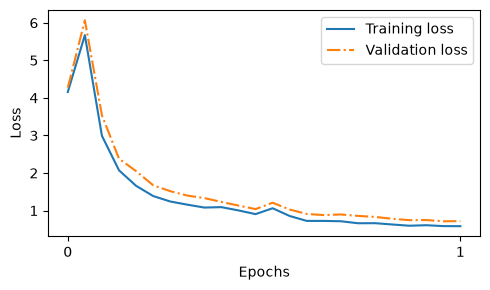

In [36]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, train_losses, val_losses)

In [37]:
import tqdm
for i,entry in tqdm.tqdm(enumerate(test_data),total=len(test_data)):
    input_text=format_input(entry)
    token_ids=generate_new_text(model=model,context_length=base_config['context_length'],max_new_tokens=256,input=text_to_token_ids(input_text,tokenizer).to(device),eos_id=50256)
    generated_text=token_ids_to_text(token_ids,tokenizer)
    response_text=generated_text[len(input_text):].replace("###Response:","").strip()
    test_data[i]['model_response']=response_text


python(9329) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
100%|██████████████████████████████████████| 110/110 [1:55:38<00:00, 63.08s/it]


In [38]:
with open("instruction-data-with-response.json",'w') as file:
    json.dump(test_data,file,indent=4)

In [39]:
file_name="gpt2-medium-355M-sft.pth"
torch.save(model.state_dict(),file_name)


In [40]:
import urllib.request
def query_model(
    prompt,
    model="llama3",
    url="http://localhost:11434/api/chat"
):
    # Create the data payload as a dictionary
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {     # Settings below are required for deterministic responses
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }


    # Convert the dictionary to a JSON formatted string and encode it to bytes
    payload = json.dumps(data).encode("utf-8")

    # Create a request object, setting the method to POST and adding necessary headers
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )
    request.add_header("Content-Type", "application/json")

    # Send the request and capture the response
    response_data = ""
    with urllib.request.urlopen(request) as response:
        # Read and decode the response
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data

In [47]:
with open("instruction-data-with-response.json",'r') as file:
    json_data=json_data = json.load(file)

In [49]:
def generate_model_scores(json_data, model="llama3"):
    scores = []
    for entry in tqdm.tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry['model_response']}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores

In [51]:
scores=generate_model_scores(json_data)

Scoring entries: 100%|███████████████████████| 110/110 [00:30<00:00,  3.55it/s]


In [54]:
sum(scores)//len(scores)

50